In [1]:
import seaborn as sns
import matplotlib.pyplot as plt
import kagglehub
import pandas as pd
import numpy as np
from sklearn.neighbors import LocalOutlierFactor
from sklearn.linear_model import LinearRegression
from sklearn.model_selection import train_test_split
from sklearn.model_selection import cross_val_score
from sklearn.metrics import mean_squared_error, mean_absolute_error

C:\Users\Johnny\AppData\Roaming\Python\Python314\site-packages\tqdm\auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


In [2]:
path = kagglehub.dataset_download(
    "nehalbirla/vehicle-dataset-from-cardekho"
)
ogdf = pd.read_csv(f"{path}/CAR DETAILS FROM CAR DEKHO.csv")
df = ogdf.copy()
third = int(len(df)/3)
#dff is for part f, the first third has been removed as it is the test data
dff = df.iloc[third:].copy()
dffValidation = df.iloc[:third].copy()
#df.head()

# Dataset 1 - Vehicle dataset
by John Lopes

## Description

"This dataset contains information about used cars.
This data can be used for a lot of purposes such as price prediction to exemplify the use of linear regression in Machine Learning."

key features:
1. name
2. year
3. selling_price
4. km_driven
5. fuel
6. seller_type
7. transmission
8. Owner

## Code

## a)

In [3]:
#wrong indices
indiciesMask = []

#look up
transmissionValues = ["Automatic", "Manual"]
transmissionInvalid = df.loc[~df["transmission"].isin(transmissionValues)].index.tolist()
indiciesMask.extend(transmissionInvalid)

fuelValues = ["Diesel", "Petrol", "CNG", "LPG", "Electric"]
fuelInvalid = df.loc[~df["fuel"].isin(fuelValues)].index.tolist()
indiciesMask.extend(fuelInvalid)

In [4]:
#presence
nullMask = df.isnull().any(axis=1)
emptyMask = (df == "").any(axis=1)

emptyRows = df[nullMask | emptyMask]
emptyIndices = emptyRows.index.tolist()
indiciesMask.extend(emptyIndices)

In [5]:
df = df.drop(indiciesMask, axis="index")

## b)

In [6]:
#did not encode the name column due to unique values
dfEncoded = pd.get_dummies(df.copy(), columns=["fuel", "transmission", "owner", "seller_type"], drop_first=False,dtype=int)
dfAggregate = dfEncoded.copy()
dfEncoded.head()
#print(df["fuel"])
#print(dfEncoded["fuel_Diesel"])

,name,year,selling_price,km_driven,fuel_CNG,fuel_Diesel,fuel_Electric,fuel_LPG,fuel_Petrol,transmission_Automatic,transmission_Manual,owner_First Owner,owner_Fourth & Above Owner,owner_Second Owner,owner_Test Drive Car,owner_Third Owner,seller_type_Dealer,seller_type_Individual,seller_type_Trustmark Dealer
0,Maruti 800 AC,2007,60000,70000,0,0,0,0,1,0,1,1,0,0,0,0,0,1,0
1,Maruti Wagon R LXI Minor,2007,135000,50000,0,0,0,0,1,0,1,1,0,0,0,0,0,1,0
2,Hyundai Verna 1.6 SX,2012,600000,100000,0,1,0,0,0,0,1,1,0,0,0,0,0,1,0
3,Datsun RediGO T Option,2017,250000,46000,0,0,0,0,1,0,1,1,0,0,0,0,0,1,0
4,Honda Amaze VX i-DTEC,2014,450000,141000,0,1,0,0,0,0,1,0,0,1,0,0,0,1,0


## c)

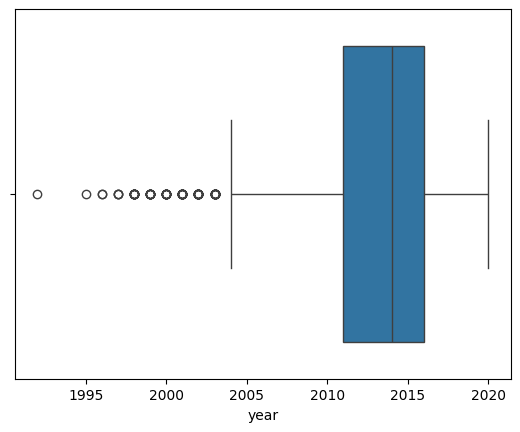

In [7]:
yearPlot = sns.boxplot(df,x="year")

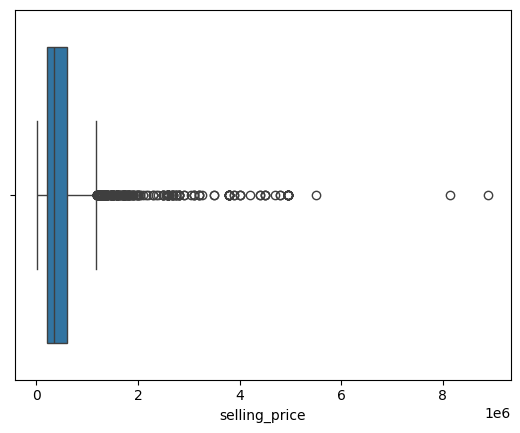

In [8]:
sellingPrice = sns.boxplot(df,x="selling_price")

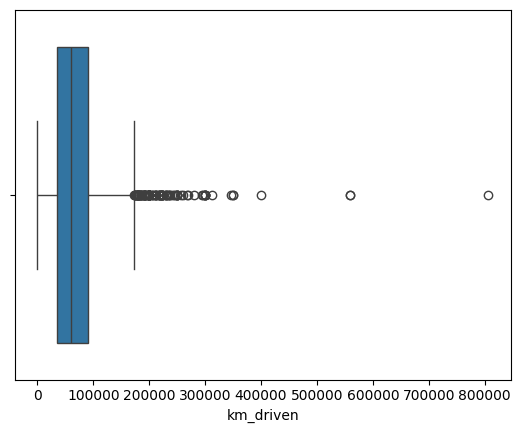

In [9]:
kmDriven = sns.boxplot(df,x="km_driven")

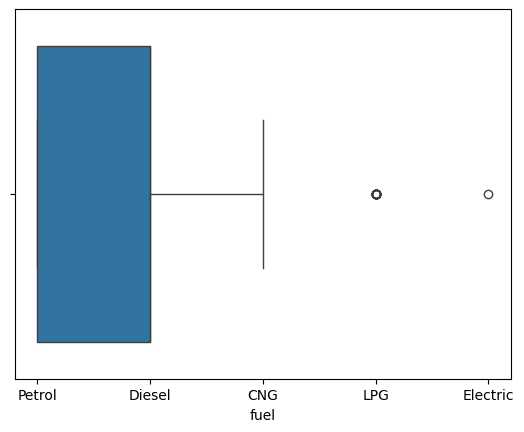

In [10]:
fuelPlot = sns.boxplot(df,x="fuel")

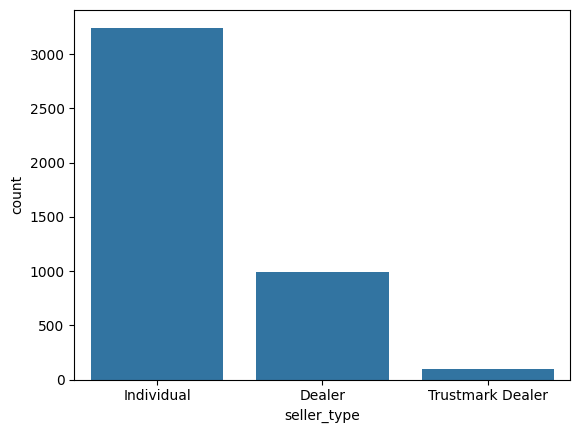

In [11]:
sellerPlot = sns.countplot(df,x="seller_type")

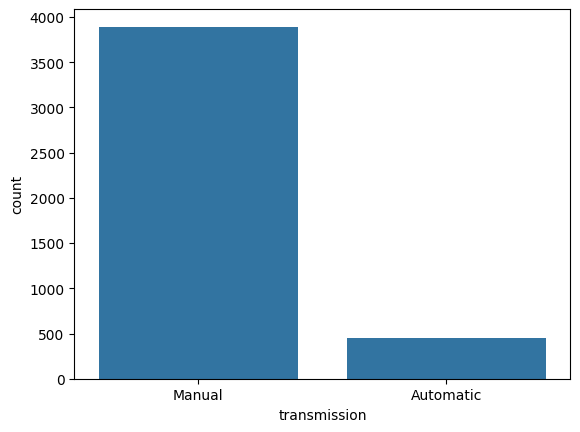

In [12]:
transmissionPlot = sns.countplot(df,x="transmission")

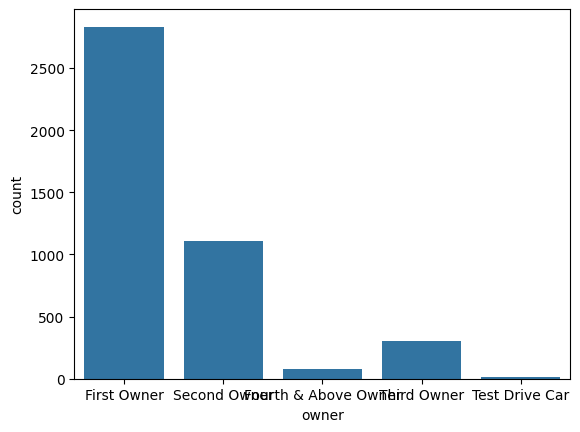

In [13]:
ownerPlot = sns.countplot(df,x="owner")

In [14]:
lof = LocalOutlierFactor(n_neighbors=20, contamination=0.05)

cols = [col for col in dfEncoded.columns if col not in ["name"]]
dfEncoded["lof_label"] = lof.fit_predict(dfEncoded[cols])

dfEncoded[dfEncoded["lof_label"] == -1].head()

,name,year,selling_price,km_driven,fuel_CNG,fuel_Diesel,fuel_Electric,fuel_LPG,fuel_Petrol,transmission_Automatic,transmission_Manual,owner_First Owner,owner_Fourth & Above Owner,owner_Second Owner,owner_Test Drive Car,owner_Third Owner,seller_type_Dealer,seller_type_Individual,seller_type_Trustmark Dealer,lof_label
32,Audi Q5 2.0 TDI,2011,1190000,175900,0,1,0,0,0,1,0,1,0,0,0,0,1,0,0,-1
56,Hyundai i20 Sportz 1.4 CRDi,2018,750000,29000,0,1,0,0,0,0,1,1,0,0,0,0,1,0,0,-1
57,Maruti Omni Maruti Omni MPI STD BSIII 5-STR W/...,2018,310000,28000,0,0,0,0,1,0,1,1,0,0,0,0,1,0,0,-1
69,Chevrolet Tavera Neo LS B3 - 7(C) seats BSIII,2010,280000,350000,0,1,0,0,0,0,1,0,0,1,0,0,0,1,0,-1
70,Toyota Corolla Altis Diesel D4DG,2011,350000,230000,0,1,0,0,0,0,1,1,0,0,0,0,0,1,0,-1


In [15]:
print(dfEncoded[dfEncoded["lof_label"]==-1])
#removing outliers
dfEncoded = dfEncoded[dfEncoded["lof_label"]!=-1]
print(dfEncoded[dfEncoded["lof_label"]==-1])
# dfEncoded.head()

                                                   name  year  selling_price  \
32                                      Audi Q5 2.0 TDI  2011        1190000   
56                          Hyundai i20 Sportz 1.4 CRDi  2018         750000   
57    Maruti Omni Maruti Omni MPI STD BSIII 5-STR W/...  2018         310000   
69        Chevrolet Tavera Neo LS B3 - 7(C) seats BSIII  2010         280000   
70                     Toyota Corolla Altis Diesel D4DG  2011         350000   
...                                                 ...   ...            ...   
4282                            Maruti Wagon R LX Minor  2013         290000   
4294                          Mahindra XUV500 AT W8 FWD  2015         740000   
4326                                 Honda City 1.5 GXI  2005          65000   
4331               Ford EcoSport 1.5 TDCi Titanium BSIV  2015         530000   
4334       Toyota Innova 2.5 VX (Diesel) 8 Seater BS IV  2012         600000   

      km_driven  fuel_CNG  fuel_Diesel 

## d)

Mean Squared Error (MSE): 237033905715.79865
Mean Absolute Error (MAE): 266216.1448396966
R² train: 0.19352818822559414
R² test : 0.1627607602479102


Text(0.5, 1.0, 'Linear regression year vs selling_price')

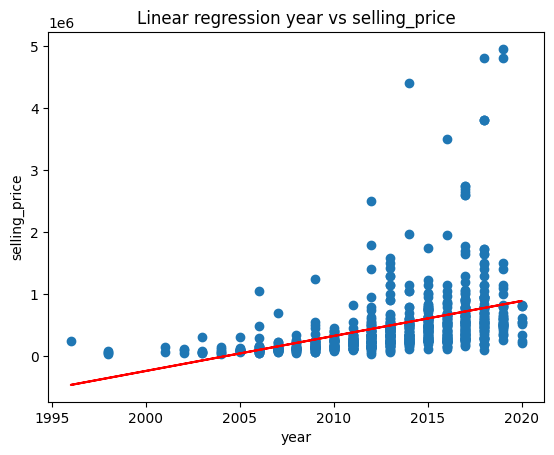

In [16]:
dfEncoded.sort_values(by="year", ascending=True)
X = dfEncoded[["year"]]
y = dfEncoded["selling_price"]

x_train, x_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

model = LinearRegression().fit(x_train, y_train)

predictions = model.predict(x_test)
mse = mean_squared_error(y_test, predictions)
mae = mean_absolute_error(y_test, predictions)

print("Mean Squared Error (MSE):", mse)
print("Mean Absolute Error (MAE):", mae)
print("R² train:", model.score(x_train, y_train))
print("R² test :", model.score(x_test, y_test))

plt.scatter(x_test["year"], y_test)
plt.plot(x_test, predictions, color="red")
plt.xlabel("year")
plt.ylabel("selling_price")
plt.title("Linear regression year vs selling_price")

## e)

In [17]:
dfAggregate["transmission_Manual_fuel_Diesel"] = (dfAggregate["transmission_Manual"] & dfAggregate["fuel_Diesel"]).astype(int)

dfAggregate[["transmission_Manual", "fuel_Diesel", "transmission_Manual_fuel_Diesel"]].head()
#dfAggregate.head()

,transmission_Manual,fuel_Diesel,transmission_Manual_fuel_Diesel
0,1,0,0
1,1,0,0
2,1,1,1
3,1,0,0
4,1,1,1


## f) 

Mean Squared Error (MSE): 157734717023.8349
Mean Absolute Error (MAE): 224272.55891388777
R² train: 0.23788736671201272
R² test : 0.1844625076500176


Text(0.5, 1.0, 'Linear regression year vs selling_price w/o outliers')

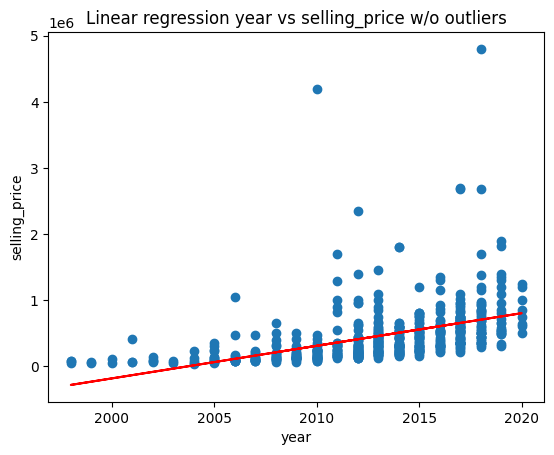

In [18]:
#removed outliers
dffEncoded = pd.get_dummies(dff.copy(), columns=["fuel", "transmission", "owner", "seller_type"], drop_first=False, dtype=int)
lof = LocalOutlierFactor(n_neighbors=20, contamination=0.05)
cols = [col for col in dffEncoded.columns if col not in ["name"]]
dffEncoded["lof_label"] = lof.fit_predict(dffEncoded[cols])
dffEncoded["lof_score"] = lof.negative_outlier_factor_
dffEncoded = dffEncoded[dffEncoded["lof_label"]!=-1]

x = dffEncoded[["year"]]
y = dffEncoded["selling_price"]
x_train, x_test, y_train, y_test = train_test_split(x, y, test_size=0.2, random_state=42)

modelo = LinearRegression().fit(x_train, y_train)

predictions = modelo.predict(x_test)
mse = mean_squared_error(y_test, predictions)
mae = mean_absolute_error(y_test, predictions)
print("Mean Squared Error (MSE):", mse)
print("Mean Absolute Error (MAE):", mae)
print("R² train:", modelo.score(x_train, y_train))
print("R² test :", modelo.score(x_test, y_test))

plt.scatter(x_test, y_test)
plt.plot(x_test, predictions, color="red")
plt.xlabel("year")
plt.ylabel("selling_price")
plt.title("Linear regression year vs selling_price w/o outliers")

Mean Squared Error (MSE): 376702460956.79126
Mean Absolute Error (MAE): 344351.922472326
R² train: 0.13459147411476424
R² test : 0.1206230667285253


Text(0.5, 1.0, 'Linear regression year vs selling_price w/ aggregation')

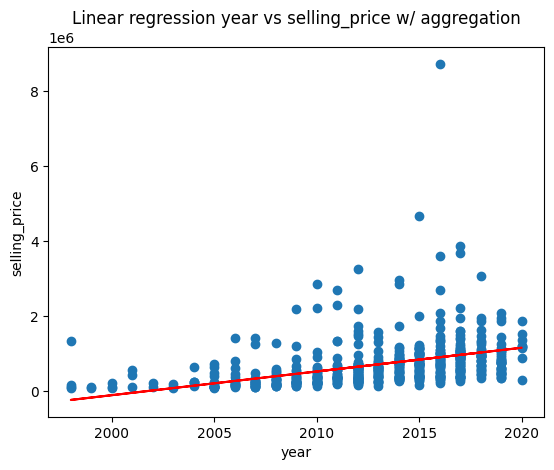

In [19]:
#aggregate features
dfffEncoded = pd.get_dummies(dff.copy(), columns=["fuel", "transmission", "owner", "seller_type"], drop_first=False, dtype=int)
#based on data, changing prices back to estimated original values based on km_driven
#print(dfffEncoded[[ "selling_price", "km_driven" ]].head())
for idx, row in dfffEncoded.iterrows():
    if row['km_driven'] > 150000:
        dfffEncoded.at[idx, 'selling_price'] = int(row['selling_price'] / 0.35)
    elif row['km_driven'] > 100000:
        dfffEncoded.at[idx, 'selling_price'] = int(row['selling_price'] / 0.50)
    elif row['km_driven'] > 60000:
        dfffEncoded.at[idx, 'selling_price'] = int(row['selling_price'] / 0.63)
    elif row['km_driven'] > 20000:
        dfffEncoded.at[idx, 'selling_price'] = int(row['selling_price'] / 0.75)
    else:
        dfffEncoded.at[idx, 'selling_price'] = int(row['selling_price'] / 0.88)
#print(dfffEncoded[[ "selling_price", "km_driven" ]].head())

x = dfffEncoded[["year"]]
y = dfffEncoded["selling_price"]
x_train, x_test, y_train, y_test = train_test_split(x, y, test_size=0.2, random_state=42)

modela = LinearRegression().fit(x_train, y_train)

predictions = modela.predict(x_test)
mse = mean_squared_error(y_test, predictions)
mae = mean_absolute_error(y_test, predictions)
print("Mean Squared Error (MSE):", mse)
print("Mean Absolute Error (MAE):", mae)
print("R² train:", modela.score(x_train, y_train))
print("R² test :", modela.score(x_test, y_test))

plt.scatter(x_test, y_test)
plt.plot(x_test, predictions, color="red")
plt.xlabel("year")
plt.ylabel("selling_price")
plt.title("Linear regression year vs selling_price w/ aggregation")

Mean Squared Error (MSE): 169328002258.8462
Mean Absolute Error (MAE): 291452.27717290545
R² train: 0.17415084900199218
R² test : 0.222272430584603


Text(0.5, 1.0, 'Linear regression year vs selling_price w/ aggregation & w/o outliers')

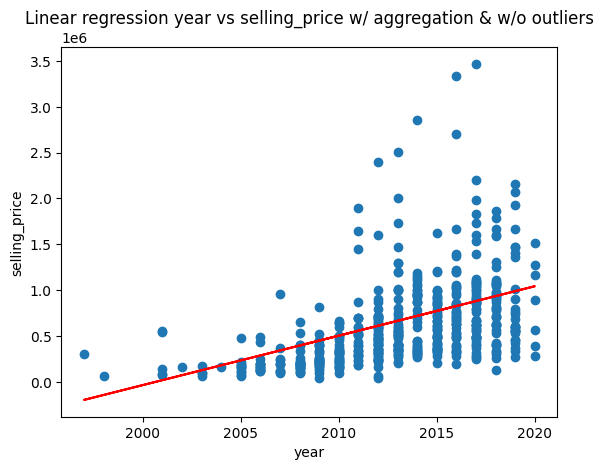

In [20]:
#aggregate features & removed outliers 
dffffEncoded = pd.get_dummies(dff.copy(), columns=["fuel", "transmission", "owner", "seller_type"], drop_first=False, dtype=int)
#print(dffffEncoded[[ "selling_price", "km_driven" ]].head())
for idx, row in dffffEncoded.iterrows():
    if row['km_driven'] > 150000:
        dffffEncoded.at[idx, 'selling_price'] = int(row['selling_price'] / 0.35)
    elif row['km_driven'] > 100000:
        dffffEncoded.at[idx, 'selling_price'] = int(row['selling_price'] / 0.50)
    elif row['km_driven'] > 60000:
        dffffEncoded.at[idx, 'selling_price'] = int(row['selling_price'] / 0.63)
    elif row['km_driven'] > 20000:
        dffffEncoded.at[idx, 'selling_price'] = int(row['selling_price'] / 0.75)
    else:
        dffffEncoded.at[idx, 'selling_price'] = int(row['selling_price'] / 0.88)
#print(dffffEncoded[[ "selling_price", "km_driven" ]].head())

lof = LocalOutlierFactor(n_neighbors=20, contamination=0.05)
cols = [col for col in dffffEncoded.columns if col not in ["name"]]
dffffEncoded["lof_label"] = lof.fit_predict(dffffEncoded[cols])
dffffEncoded["lof_score"] = lof.negative_outlier_factor_
dffffEncoded = dffffEncoded[dffffEncoded["lof_label"]!=-1]

x = dffffEncoded[["year"]]
y = dffffEncoded["selling_price"]
x_train, x_test, y_train, y_test = train_test_split(x, y, test_size=0.2, random_state=42)

modelao = LinearRegression().fit(x_train, y_train)

predictions = modelao.predict(x_test)
mse = mean_squared_error(y_test, predictions)
mae = mean_absolute_error(y_test, predictions)
print("Mean Squared Error (MSE):", mse)
print("Mean Absolute Error (MAE):", mae)
print("R² train:", modelao.score(x_train, y_train))
print("R² test :", modelao.score(x_test, y_test))

plt.scatter(x_test, y_test)
plt.plot(x_test, predictions, color="red")
plt.xlabel("year")
plt.ylabel("selling_price")
plt.title("Linear regression year vs selling_price w/ aggregation & w/o outliers")

In [21]:
#aggregate features & removed outliers had the highest R² test score
dffValidation = pd.get_dummies(dff.copy(), columns=["fuel", "transmission", "owner", "seller_type"], drop_first=False, dtype=int)
#print(dffValidation[[ "selling_price", "km_driven" ]].head())
# for idx, row in dffValidation.iterrows():
#     if row['km_driven'] > 150000:
#         dffValidation.at[idx, 'selling_price'] = int(row['selling_price'] / 0.35)
#     elif row['km_driven'] > 100000:
#         dffValidation.at[idx, 'selling_price'] = int(row['selling_price'] / 0.50)
#     elif row['km_driven'] > 60000:
#         dffValidation.at[idx, 'selling_price'] = int(row['selling_price'] / 0.63)
#     elif row['km_driven'] > 20000:
#         dffValidation.at[idx, 'selling_price'] = int(row['selling_price'] / 0.75)
#     else:
#         dffValidation.at[idx, 'selling_price'] = int(row['selling_price'] / 0.88)
# #print(dffValidation[[ "selling_price", "km_driven" ]].head())

# lof = LocalOutlierFactor(n_neighbors=20, contamination=0.05)
# cols = [col for col in dffValidation.columns if col not in ["name"]]
# dffValidation["lof_label"] = lof.fit_predict(dffValidation[cols])
# dffValidation["lof_score"] = lof.negative_outlier_factor_
# dffValidation = dffValidation[dffValidation["lof_label"]!=-1]

x = dffValidation[["year"]]
y = dffValidation["selling_price"]

# sklearn's scoring uses NEGATIVE MSE (or NEG RMSE). we take abs() afterward
scores = cross_val_score(
    modelao,
    x,
    y,
    scoring="r2",  # sklearn>=1.0
    cv=4,
    n_jobs=-1,
)

rmses = -scores  # convert from negative to positive RMSE
print("R² per fold:", scores)
print("Mean R²:", scores.mean())
print("Std R²:", scores.std())

# x_train, x_test, y_train, y_test = train_test_split(x, y, test_size=0.2, random_state=42)

# model = LinearRegression().fit(x_train, y_train)

# predictions = model.predict(x_test)
# mse = mean_squared_error(y_test, predictions)
# mae = mean_absolute_error(y_test, predictions)
# print("Mean Squared Error (MSE):", mse)
# print("Mean Absolute Error (MAE):", mae)
# print("R² train:", model.score(x_train, y_train))
# print("R² test :", model.score(x_test, y_test))

# plt.scatter(x_test, y_test)
# plt.plot(x_test, predictions, color="red")
# plt.xlabel("year")
# plt.ylabel("selling_price")
# plt.title("Linear regression year vs selling_price w/ aggregation & w/o outliers")

R² per fold: [0.22953712 0.15923333 0.20519814 0.13072805]
Mean R²: 0.18117416041882106
Std R²: 0.038543278131383966


## g)

    a. There was an improvement from the base linear regression, R² test : 0.1627607602479102, to the final linear regression that had outliers removed as well as aggregating the data to have a cars original prize compared to its marked down price, R² test : 0.222272430584603.
    b. Outlier detection is important because it is used to remove noise that could lead to lower accuracy in the model. Aggregation helped as well, though I am not sure why it did so in this situation.
    c. 

## References

Localoutlierfactor. scikit. (n.d.). https://scikit-learn.org/stable/modules/generated/sklearn.neighbors.LocalOutlierFactor.html 

GeeksforGeeks. (2025, July 11). Python: Linear regression using sklearn. https://www.geeksforgeeks.org/machine-learning/python-linear-regression-using-sklearn/ 

HelloMotors Corp. (2025, April 8). How mileage affects used car prices in Ontario - Hello Motors dealership: Auto Financing. Hello Motors Dealership | Auto Financing. https://hellomotors.ca/blog/how-mileage-affects-used-car-prices-in-ontario 